In [24]:
import seaborn

import pandas as pd
import numpy as np
simmap_file = '../ped-sim/refined_mf.simmap'

count_ambi = False
count_doubles = False

In [1]:
from sex_inference_analysis import main

sibs_av_F_input30 = "../ped-sim/outputs/sex-inference/sibs-aunt-F.seg"
sibs_av_F_output30 = f'results/sibs_AV_F_results.txt'

sibs_av_M_input30 = "../ped-sim/outputs/sex-inference/sibs-av-M.seg"
sibs_av_M_output30 = f'results/sibs_AV_M_results.txt'


main(
    input_file=sibs_av_F_input30,
    output_file=sibs_av_F_output30,
    map_file=simmap_file,
    bim="",
    window=50,
    count_ambiguous_co=count_ambi,
    count_doubles=count_doubles
)

main(
    input_file=sibs_av_M_input30,
    output_file=sibs_av_M_output30,
    map_file=simmap_file,
    bim="",
    window=50,
    count_ambiguous_co=count_ambi,
    count_doubles=count_doubles
)

df_sibs_av_F_30 = pd.read_csv(sibs_av_F_output30, sep='\t')
df_sibs_av_M_30 = pd.read_csv(sibs_av_M_output30, sep='\t')



NameError: name 'simmap_file' is not defined

In [9]:
df_sibs_av_F_30['sumf'] = df_sibs_av_F_30['p1f_len'].apply(sum)

df_sibs_av_F_30


TypeError: unsupported operand type(s) for +: 'int' and 'str'

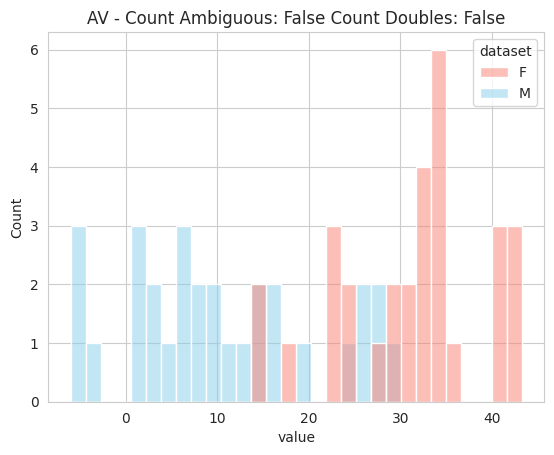

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

set1 = df_sibs_av_F_30['LOD_all']
set2 = df_sibs_av_M_30['LOD_all']


df = pd.DataFrame({
    'value': np.concatenate([set1, set2]),
    'dataset': ['F'] * len(set1) + ['M'] * len(set2)
})

# Plot
sns.histplot(
    data=df, 
    x='value', 
    hue='dataset', 
    palette={'F': 'salmon', 'M': 'skyblue'},
    alpha=0.5,
    bins=30,
    kde=False
)

plt.title(f'AV - Count Ambiguous: {count_ambi} Count Doubles: {count_doubles}')

plt.show()

